<a href="https://colab.research.google.com/github/ContextLab/experimental-psychology/blob/main/notebooks/picture_lab_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ContextLab/experimental-psychology/blob/main/notebooks/picture_lab_analysis.ipynb)

# Picture lab analysis

### PSYC 11: Laboratory in Psychological Science

This notebook provides sample analyses for the picture (drawing) lab. It pulls data directly from the class Google Sheets, compares original vs. reproduced drawings side by side, and runs statistical tests on instruction quality.

**What we're measuring:**
- How accurately were drawings reproduced from written instructions alone?
- How many assumptions did readers have to make about each set of instructions?
- How did groups rate each other's instructions on appearance, meaning, clarity, and efficiency?

The goal is to connect these data to a broader question: *what makes a methods section effective?*

In [1]:
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

if IN_COLAB:
  !pip install -q pillow-heif

import pandas as pd
import numpy as np
import seaborn as sns
import requests
import os
import warnings

from matplotlib import pyplot as plt
from plotly import express as px
from PIL import Image
from bs4 import BeautifulSoup
from scipy.stats import ttest_rel, ttest_ind
from collections import OrderedDict

with warnings.catch_warnings():
  warnings.simplefilter('ignore')
  from statsmodels.stats.anova import AnovaRM

try:
  from pillow_heif import register_heif_opener
  register_heif_opener()
except ImportError:
  pass

sns.set_theme(style='whitegrid', font_scale=1.1)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 20.2 MB/s eta 0:00:00


In [2]:
def get_data(id, mapper=None, columns=None):
  url = 'https://docs.google.com/spreadsheets/d/{0}/gviz/tq?tqx=out:csv&sheet={1}'.format(
      id,
      '0')

  data = pd.read_csv(url)
  if 'Timestamp' in data.columns:
    data = data.drop('Timestamp', axis=1)

  if mapper is not None:
    data = data.rename(mapper, axis=1)
  elif columns is not None:
    # Handle column count mismatches (e.g., if the form added new columns)
    if len(columns) < len(data.columns):
      data = data.iloc[:, :len(columns)]
    data.columns = columns

  return data.sort_values(by='group')

---
# 1. Download raw data

We have three Google Sheets containing class data:
1. **Original drawings and instructions** — each group's drawing, its title, and the written instructions
2. **Reproductions** — each group's attempt at reproducing every other group's drawing, along with assumed titles and stated assumptions
3. **Ratings** — how each group rated every other group's instructions on appearance, meaning, clarity, and efficiency (1–10 scale)

In [3]:
# original pictures and instructions
id = '1Qpj4M3xhDO__6fIp6_Yqk9OR8Yrddk18UeXJcqgbQuw'
columns = ['group', 'drawing url', 'title', 'instructions']
drawings = get_data(id, columns=columns)
drawings

,group,drawing url,title,instructions
1,A,https://drive.google.com/open?id=1i_q4IkT0284r...,Rocketship,https://drive.google.com/open?id=1LWe9bzSBASW2...
2,B,https://drive.google.com/open?id=1AngYHmchVXKv...,Bingus the Cat,https://drive.google.com/open?id=1buVILYNgEcz3...
0,C,https://drive.google.com/open?id=1X2KgMHbYT7tf...,FOXY,https://drive.google.com/open?id=1u5mQd4QFHbSU...
3,D,https://drive.google.com/open?id=19DDLczjFIQxm...,Space Cat,https://drive.google.com/open?id=15DFeoP2MzKyn...


In [4]:
# drawing reproductions
id = '1fjCyZ3Mfuw_iy4Y-yG5N1pcSH8Z-D8movhPBk0f6Esw'
columns = ['group',
           'A repro', 'A title', 'A assumptions',
           'B repro', 'B title', 'B assumptions',
           'C repro', 'C title', 'C assumptions',
           'D repro', 'D title', 'D assumptions']
reproductions = get_data(id, columns=columns)
reproductions

,group,A repro,A title,A assumptions,B repro,B title,B assumptions,C repro,C title,C assumptions,D repro,D title,D assumptions
0,A,https://drive.google.com/open?id=1QApqwBJTCUaU...,Rocketship,NaN,https://drive.google.com/open?id=1h9u2_98LuNF6...,Cat,Assuming “medium size”\nAssuming orientation o...,https://drive.google.com/open?id=1PSpvnJ3eJ-ep...,Star-nosed mole,"Where is “middle upper”\nWhat is “big,” “mediu...",https://drive.google.com/open?id=1MNF0ZSiR39o_...,Lion flag,Assumes the drawer knows the size of a quarter...
3,B,https://drive.google.com/open?id=1TMAN6wetro1i...,Rocket,"The position of the triangles at the bottom, w...",https://drive.google.com/open?id=1pSb5F1ZJjSIw...,Cat,Assumed that the quarter circles were connecte...,https://drive.google.com/open?id=1K_h4C0lYTYTl...,Animal,Assumption that the size of the eyes and the p...,https://drive.google.com/open?id=1SMZYrtqZI6Ed...,Royal Cat,Assumption that the circle on top of the circl...
1,C,https://drive.google.com/open?id=127uoaFVqVkni...,Rocket,"Fill this in with white is confusing, the shee...",https://drive.google.com/open?id=1KkwNermOOpD7...,Cat,“Medium size circle” is quite arbitrary\nWhat ...,https://drive.google.com/open?id=18K56-8CqGbA1...,Foxy,The width of the vertical oval is not specifie...,https://drive.google.com/open?id=1rjPPKyQbcbAM...,Cat,Each corner of the rectangle doesn’t specify h...
2,D,https://drive.google.com/open?id=1713cRNaIuPh8...,Rocketship,Group A Assumptions \n\nStep 2: Assume that ⅛ ...,https://drive.google.com/open?id=1-gUGNwaK0QkR...,Cat,Step b: What is medium sized? What is the top ...,https://drive.google.com/open?id=1FUtnC9Uq7Hnq...,Fox,Step 2: did not tell us what utensil to use\nS...,https://drive.google.com/open?id=1Nbw446vXuXkr...,space seal,Step 4: How far from each corner is the star\n...


In [5]:
# ratings
id = '1kwYA6_Z81FwA2oLkBVrCtjnFO5v15UNNVeZF5dXYX6w'
columns = ['group',
           'eval spreadsheet',
           'assumptions spreadsheet',
           'appearance A', 'appearance B', 'appearance C', 'appearance D',
           'meaning A', 'meaning B', 'meaning C', 'meaning D',
           'clarity A', 'clarity B', 'clarity C', 'clarity D',
           'efficiency A', 'efficiency B', 'efficiency C', 'efficiency D']
ratings = get_data(id, columns=columns)

# Which groups submitted ratings?
submitted_groups = sorted(ratings['group'].unique())
all_groups = sorted(drawings['group'].unique())
print(f'Groups with ratings data: {", ".join(submitted_groups)}')
ratings

Groups with ratings data: A, B, C, D


,group,eval spreadsheet,assumptions spreadsheet,appearance A,appearance B,appearance C,appearance D,meaning A,meaning B,meaning C,meaning D,clarity A,clarity B,clarity C,clarity D,efficiency A,efficiency B,efficiency C,efficiency D
1,A,https://drive.google.com/open?id=1dHsu_NS0wwXE...,https://drive.google.com/open?id=1UAr5TiJ9Fj5B...,10,10,10,7,10,10,5,1,10,9,8,5,8,8,8,1
3,B,https://drive.google.com/open?id=1ryIlYqtw710l...,https://drive.google.com/open?id=1gFpfzyoIAM_W...,7,6,9,7,10,10,5,3,8,7,8,5,9,8,6,4
0,C,https://drive.google.com/open?id=1uLAP3jRKUmIO...,https://drive.google.com/open?id=1kxLfy3xaezNB...,9,5,9,8,10,10,10,2,7,9,8,4,7,9,7,2
2,D,https://drive.google.com/open?id=1JvJzOWj8c3JQ...,https://drive.google.com/open?id=1yaaDYZx1lOvd...,5,7,8,8,3,8,9,4,6,2,7,8,1,7,5,6


---
# 2. Compare original vs. reproduced drawings

For each group, we display the original drawing alongside reproductions made by groups A, B, C, and D (in that order, left to right). This lets us visually assess how well each set of instructions communicated the drawing.

In [6]:
def get_fname(url):
  id = url[str.find(url, '?id=')+4:]
  response = requests.get(url, stream=True)
  lines = [line.decode() for line in response.iter_lines()]
  soup = BeautifulSoup('\n'.join(lines), 'html.parser')
  return soup.find_all('title')[0].string.replace(' - Google Drive', '')

def get_image(url, height=250):
  id = url[str.find(url, '?id=')+4:]
  fname = get_fname(url)
  tmp, ext = os.path.splitext(fname)
  view_url = f'https://drive.google.com/uc?export=view&id={id}'

  if not os.path.exists(fname):
    response = requests.get(view_url, stream=True)
    with open(fname, 'wb+') as f:
      for chunk in response.iter_content(1024):
        if not chunk:
          break
        f.write(chunk)

  # PIL handles HEIC natively when pillow-heif is registered
  x = Image.open(fname).convert('RGB')
  return x.resize((int(x.size[0] * height / x.size[1]), height))

def im2array(img):
  return np.array(img)

def stack_images(urls, height=250, bwidth=10):
  if type(urls) is str:
    return im2array(get_image(urls, height=height))

  border = np.zeros((height, bwidth, 3), dtype=np.uint8)
  x = im2array(get_image(urls[0], height=height))
  for i in range(1, len(urls)):
    nxt = im2array(get_image(urls[i], height=height))
    x = np.concatenate([x, border, nxt], axis=1)

  return x

def display_image_set(urls, height=250, bwidth=10, figsize=10, ax=None):
  x = stack_images(urls, height=height, bwidth=bwidth)

  if ax is None:
    fig = plt.figure(figsize=(figsize, figsize * (x.shape[0] / x.shape[1])))
    ax = plt.gca()
  ax.imshow(x)
  ax.set_xticks([])
  ax.set_yticks([])
  return plt.gcf()

In [7]:
def compare_drawings(group):
  orig_url = drawings.query(f'group == "{group}"')['drawing url'].values[0]
  orig_title = drawings.query(f'group == "{group}"')['title'].values[0]

  # Sort reproductions by group label (A, B, C, D)
  sorted_repros = reproductions.sort_values('group')
  repo_urls = sorted_repros[f'{group} repro'].values
  repo_titles = sorted_repros[f'{group} title'].values
  repo_groups = sorted_repros['group'].values

  fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                           gridspec_kw={'width_ratios': [1, 3]})

  # Original
  orig_img = im2array(get_image(orig_url, height=300))
  axes[0].imshow(orig_img)
  axes[0].set_title(f'Original: "{orig_title}"', fontsize=13, fontweight='bold')
  axes[0].set_xticks([])
  axes[0].set_yticks([])

  # Reproductions (sorted by group, left to right)
  repo_img = stack_images(list(repo_urls), height=300, bwidth=5)
  axes[1].imshow(repo_img)
  labels = [f'{g}: "{t}"' if pd.notna(t) else f'{g}' for g, t in zip(repo_groups, repo_titles)]
  axes[1].set_title('Reproductions (groups ' + ', '.join(repo_groups) + ')', fontsize=13)
  axes[1].set_xticks([])
  axes[1].set_yticks([])

  fig.suptitle(f'Group {group}\'s drawing', fontsize=15, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()

  # Print what each group titled it
  print(f'  Guessed titles: ' + ', '.join(labels))

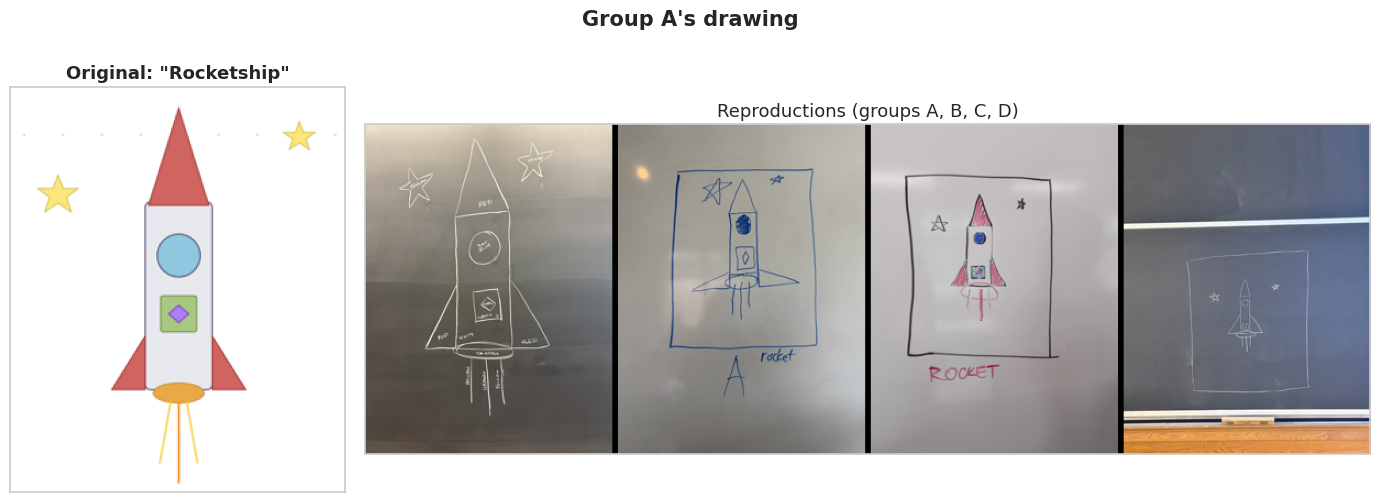

  Guessed titles: A: "Rocketship", B: "Rocket", C: "Rocket", D: "Rocketship"



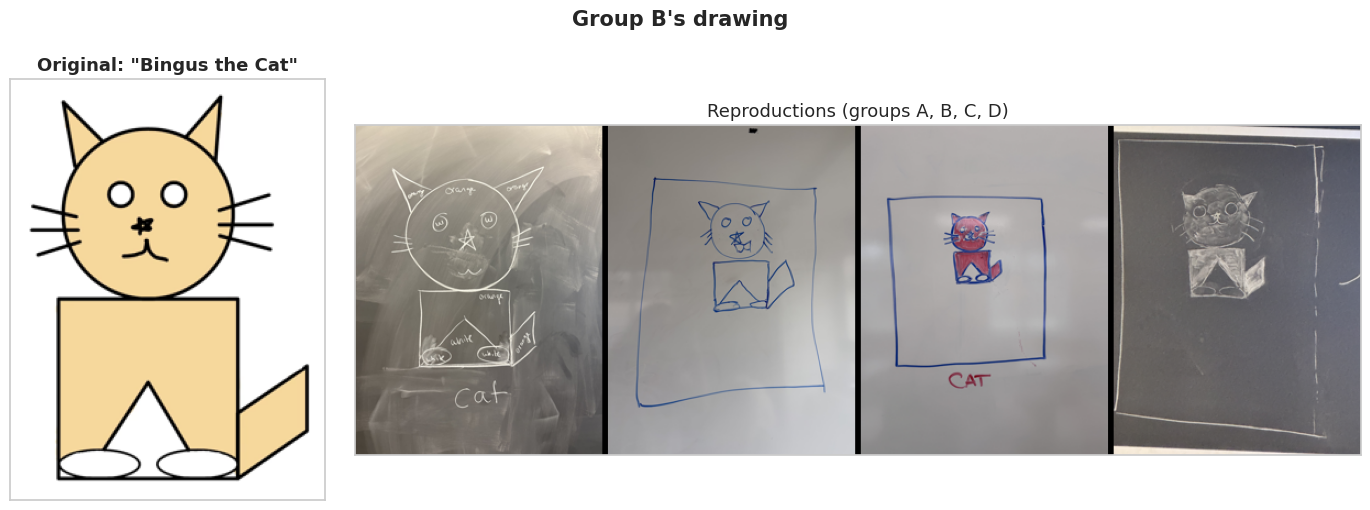

  Guessed titles: A: "Cat", B: "Cat ", C: "Cat", D: "Cat"



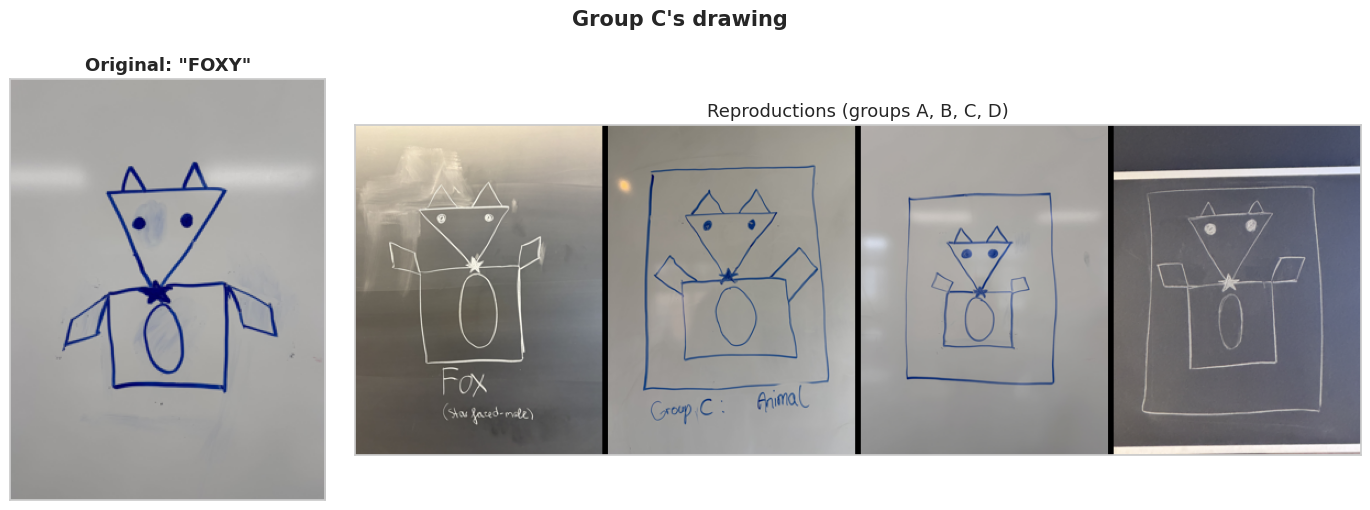

  Guessed titles: A: "Star-nosed mole", B: "Animal ", C: "Foxy", D: "Fox"



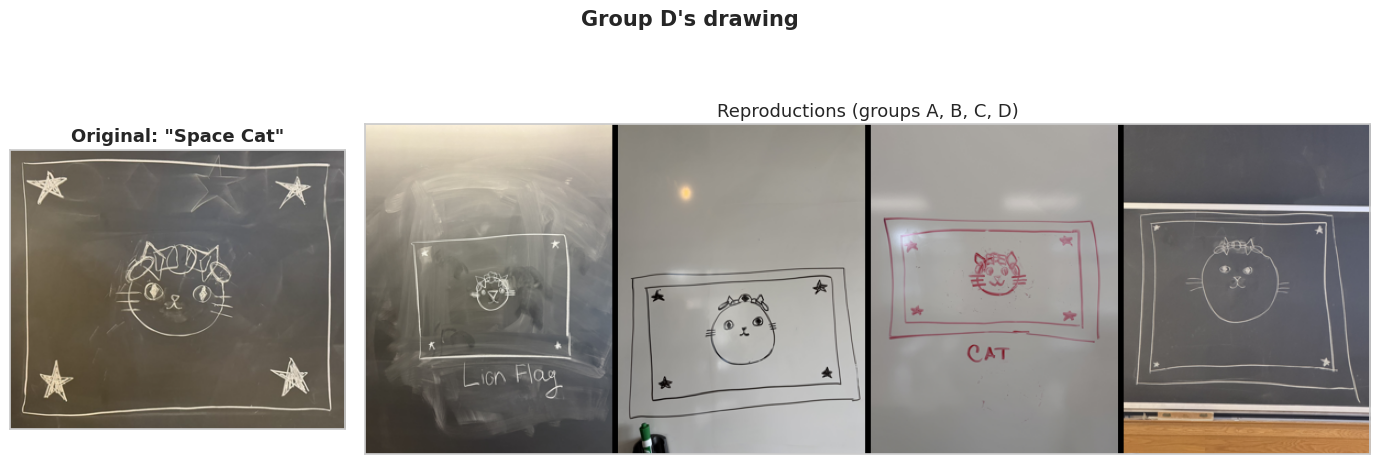

  Guessed titles: A: "Lion flag", B: "Royal Cat", C: "Cat", D: "space seal"



In [8]:
for g in all_groups:
  compare_drawings(g)
  print()

---
# 3. Evaluate quality of instructions

Each group uploaded two spreadsheets:
1. **Ratings of how well other groups followed their instructions** — for each step, a 1 (followed correctly) or 0 (not followed)
2. **Assumptions counts** — how many assumptions each group made about their instructions, plus a normalized version (assumptions / total instructions)

We also have **subjective ratings** (1–10) on four dimensions: appearance match, meaning match, clarity, and efficiency.

In [9]:
def get_id(url):
  if 'docs.google.com' in url:
    start_id = '/spreadsheets/d/'
    end_id = '/edit?usp='
    return url[str.find(url, start_id)+len(start_id):str.find(url, end_id)]
  else:
    return url[str.find(url, '?id=')+4:]

def get_ratings_df(url):
  df = get_data(get_id(url))
  df.columns = ['group', *[x for x in range(df.shape[1] - 1)]]
  return df

def get_assumptions_df(url):
  df = get_data(get_id(url), {'Group': 'group'}).iloc[:, :3]
  df.columns = ['group', 'total', 'proportion']
  return df

In [10]:
# Download instruction-following ratings and assumption counts
ratings_data = [get_ratings_df(r) for r in ratings['eval spreadsheet'].values]
assumptions_data = [get_assumptions_df(a) for a in ratings['assumptions spreadsheet'].values]

# Tag each assumptions DataFrame with its rater group
for i, g in enumerate(submitted_groups):
  assumptions_data[i] = assumptions_data[i].assign(rater=g)

compiled_assumptions = pd.concat(assumptions_data, axis=0).rename(
    {'group': 'rated', 'total': 'count'}, axis=1
)

print(f'Downloaded ratings from {len(ratings_data)} group(s)')
compiled_assumptions

Downloaded ratings from 4 group(s)


,rated,count,proportion,rater
0,A,0.0,0.000000,A
1,B,2.0,0.200000,A
2,C,6.0,0.600000,A
3,D,5.0,0.500000,A
0,A,4.0,0.267000,B
1,B,1.0,0.067000,B
2,C,4.0,0.267000,B
3,D,8.0,0.533000,B
0,A,1.0,1.000000,C
4,A,NaN,NaN,C


---
## 3a. How well were each group's instructions followed?

For each group's drawing, we plot the proportion of instructions that were followed correctly by other groups, broken down by instruction number. Each line represents one group's *instructions being evaluated* (not who did the evaluating). The shaded region shows ±1 standard error across raters.

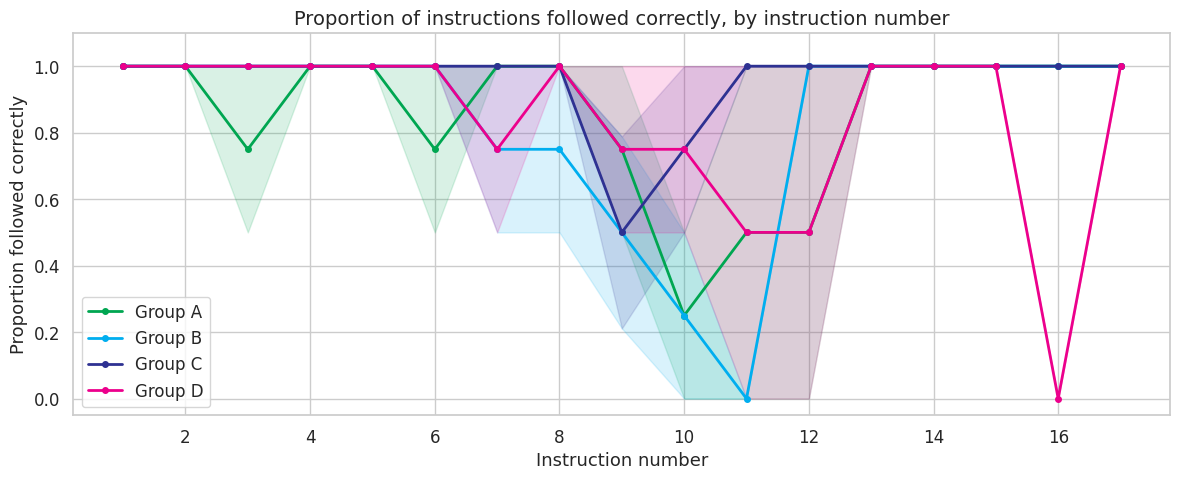

In [11]:
# Restructure: for each rated group, collect all raters' instruction-following data
# Each rater's spreadsheet has rows for each group they rated, with columns for each instruction

def get_instruction_data_for_group(rated_group):
  """Collect instruction-following data for a given group across all raters."""
  rows = []
  for i, rater_df in enumerate(ratings_data):
    df_numeric = rater_df.set_index('group').apply(pd.to_numeric, errors='coerce')
    if rated_group in df_numeric.index:
      row = df_numeric.loc[rated_group]
      if isinstance(row, pd.DataFrame):
        rows.extend(row.values.tolist())
      else:
        rows.append(row.values.tolist())
  if not rows:
    return None
  # Pad rows to same length (different groups may have different numbers of instructions)
  max_len = max(len(r) for r in rows)
  padded = [r + [np.nan] * (max_len - len(r)) for r in rows]
  return np.array(padded)

fig, ax = plt.subplots(figsize=(12, 5))
colors = {'A': '#00A651', 'B': '#00AEEF', 'C': '#2E3192', 'D': '#EC008C'}

for g in all_groups:
  data = get_instruction_data_for_group(g)
  if data is None or data.shape[0] == 0:
    continue
  x = np.arange(data.shape[1]) + 1
  y = np.nanmean(data, axis=0)
  n_valid = np.sum(~np.isnan(data), axis=0)
  se = np.nanstd(data, axis=0) / np.sqrt(np.maximum(n_valid - 1, 1))
  se = np.nan_to_num(se)

  ax.fill_between(x, y - se, y + se, alpha=0.15, color=colors[g])
  ax.plot(x, y, color=colors[g], label=f'Group {g}', linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Instruction number', fontsize=13)
ax.set_ylabel('Proportion followed correctly', fontsize=13)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=12)
ax.set_title('Proportion of instructions followed correctly, by instruction number', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3b. Overall instruction quality: which group's instructions were easiest to follow?

We compute the average proportion of instructions followed correctly *by other groups* (excluding self-ratings). Error bars show ±1 SE across raters.

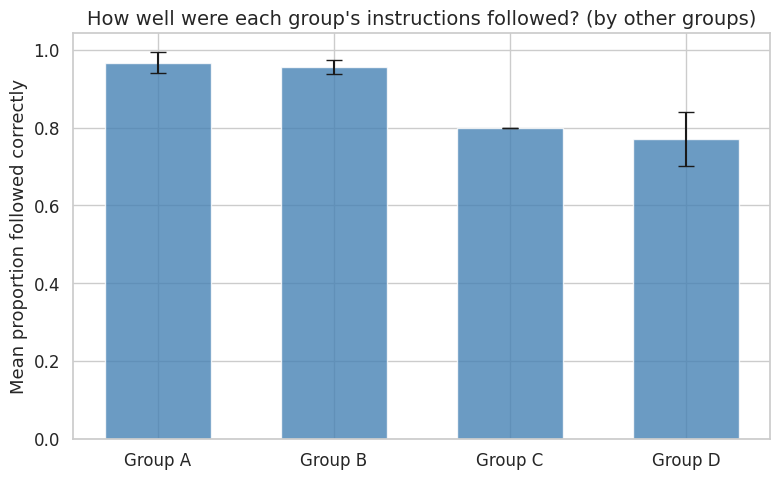

In [12]:
def bar_with_errorbars(values_per_group, groups, ylabel, title, color='steelblue'):
  """Generic grouped bar plot with error bars. Uses nan-safe functions."""
  means = [np.nanmean(v) if len(v) > 0 else 0 for v in values_per_group]
  n_valid = [np.sum(~np.isnan(v)) if len(v) > 0 else 0 for v in values_per_group]
  sems = [np.nanstd(v) / np.sqrt(nv) if nv > 1 else 0 for v, nv in zip(values_per_group, n_valid)]

  fig, ax = plt.subplots(figsize=(8, 5))
  x = np.arange(len(groups))
  ax.bar(x, means, yerr=sems, capsize=6, color=color, edgecolor='white',
         alpha=0.8, width=0.6)
  ax.set_xticks(x)
  ax.set_xticklabels([f'Group {g}' for g in groups], fontsize=12)
  ax.set_ylabel(ylabel, fontsize=13)
  ax.set_title(title, fontsize=14)
  plt.tight_layout()
  return fig

# For each rated group, collect overall mean proportion from each rater
instruction_quality = {g: [] for g in all_groups}
for i, rater_df in enumerate(ratings_data):
  rater_group = submitted_groups[i]
  df_numeric = rater_df.set_index('group').apply(pd.to_numeric, errors='coerce')
  for rated_group in df_numeric.index:
    if rated_group != rater_group:  # exclude self-ratings
      instruction_quality[rater_group].append(np.nanmean(df_numeric.loc[rated_group].values))

bar_with_errorbars(
  [instruction_quality[g] for g in all_groups], all_groups,
  'Mean proportion followed correctly',
  'How well were each group\'s instructions followed? (by other groups)'
)
plt.show()

## 3c. How good was each group at *following* others' instructions?

This is the complement of the previous plot. Instead of asking "whose instructions were clearest?", we ask "who was best at following instructions?" A group that scores high here is good at interpreting and executing procedures — a useful skill in science.

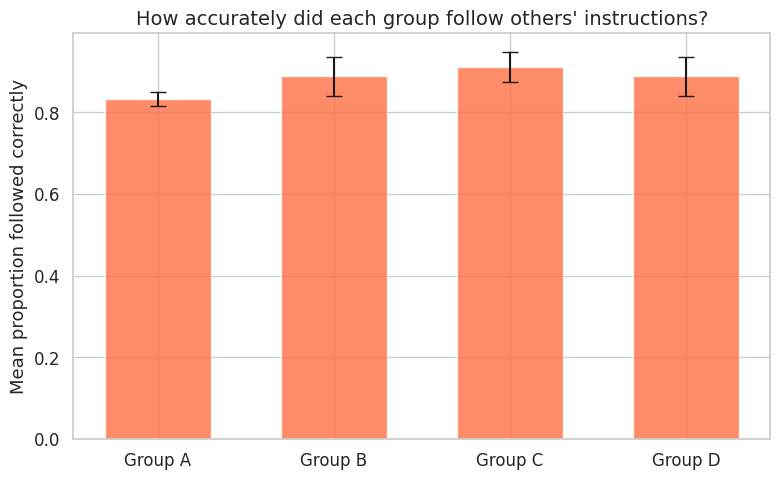

In [13]:
# For each group, collect their accuracy at following others' instructions
following_ability = {g: [] for g in all_groups}
for i, rater_df in enumerate(ratings_data):
  rater_group = submitted_groups[i]
  df_numeric = rater_df.set_index('group').apply(pd.to_numeric, errors='coerce')
  for follower_group in df_numeric.index:
    if follower_group != rater_group:  # how well did follower_group follow rater's instructions
      following_ability[follower_group].append(np.nanmean(df_numeric.loc[rater_group].values))

bar_with_errorbars(
  [following_ability[g] for g in all_groups], all_groups,
  'Mean proportion followed correctly',
  'How accurately did each group follow others\' instructions?',
  color='#FF7043'
)
plt.show()

---
## 3d. Assumptions analysis

More assumptions *might* indicate more ambiguity in the instructions — but it's not that simple. Complex instructions might require more assumptions while still producing accurate drawings. We look at both raw counts and normalized proportions (assumptions per instruction).

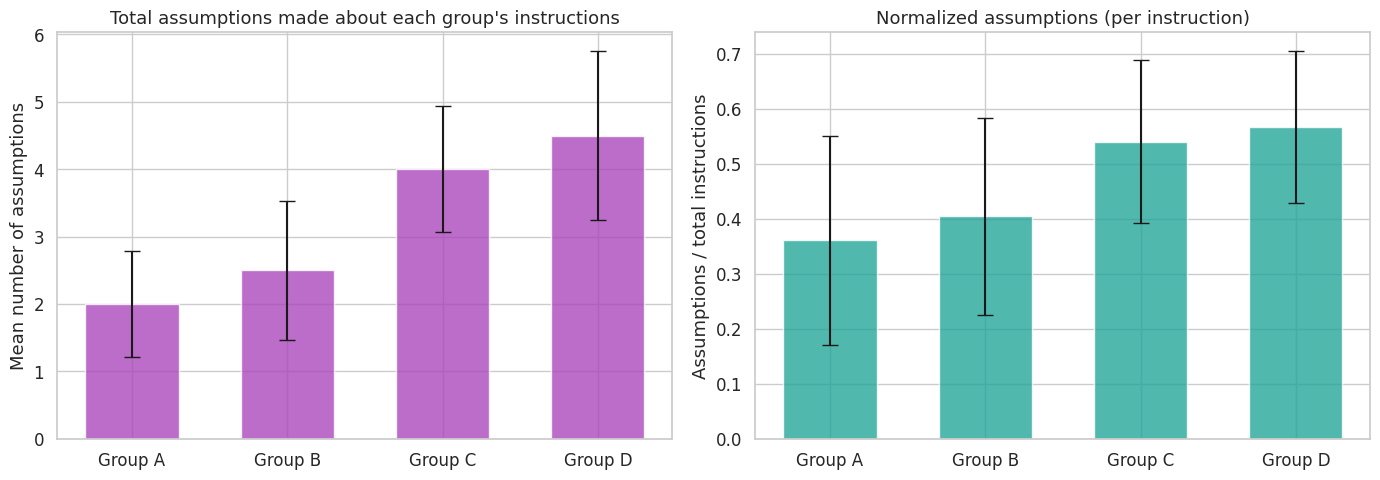

In [14]:
# Assumptions: total count per rated group (using nan-safe functions throughout)
assumption_counts = {g: compiled_assumptions.query('rated == @g')['count'].values.astype(float)
                     for g in all_groups}
assumption_props = {g: compiled_assumptions.query('rated == @g')['proportion'].values.astype(float)
                    for g in all_groups}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total assumptions
means_t = [np.nanmean(assumption_counts[g]) if len(assumption_counts[g]) > 0 else 0 for g in all_groups]
n_valid_t = [np.sum(~np.isnan(assumption_counts[g])) for g in all_groups]
sems_t = [np.nanstd(assumption_counts[g]) / np.sqrt(nv) if nv > 1 else 0
          for g, nv in zip(all_groups, n_valid_t)]
x = np.arange(len(all_groups))
axes[0].bar(x, means_t, yerr=sems_t, capsize=6, color='#AB47BC', alpha=0.8, width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Group {g}' for g in all_groups], fontsize=12)
axes[0].set_ylabel('Mean number of assumptions', fontsize=13)
axes[0].set_title('Total assumptions made about each group\'s instructions', fontsize=13)

# Normalized assumptions
means_p = [np.nanmean(assumption_props[g]) if len(assumption_props[g]) > 0 else 0 for g in all_groups]
n_valid_p = [np.sum(~np.isnan(assumption_props[g])) for g in all_groups]
sems_p = [np.nanstd(assumption_props[g]) / np.sqrt(nv) if nv > 1 else 0
          for g, nv in zip(all_groups, n_valid_p)]
axes[1].bar(x, means_p, yerr=sems_p, capsize=6, color='#26A69A', alpha=0.8, width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Group {g}' for g in all_groups], fontsize=12)
axes[1].set_ylabel('Assumptions / total instructions', fontsize=13)
axes[1].set_title('Normalized assumptions (per instruction)', fontsize=13)

plt.tight_layout()
plt.show()

### Do groups with fewer assumptions also have higher instruction-following rates?

If assumptions indicate ambiguity, we might expect a negative relationship: groups whose instructions required fewer assumptions should also have higher instruction-following accuracy.

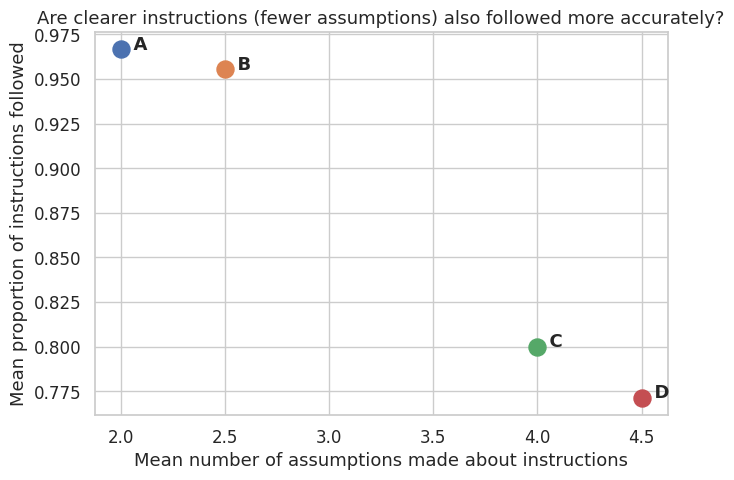

In [15]:
# Compare assumption counts to instruction quality
groups_with_data = [g for g in all_groups if len(assumption_counts[g]) > 0 and len(instruction_quality[g]) > 0]
if len(groups_with_data) >= 2:
  fig, ax = plt.subplots(figsize=(7, 5))
  for g in groups_with_data:
    ax.scatter(np.nanmean(assumption_counts[g]), np.nanmean(instruction_quality[g]),
               s=150, zorder=5, label=f'Group {g}')
    ax.annotate(f'  {g}', (np.nanmean(assumption_counts[g]), np.nanmean(instruction_quality[g])),
                fontsize=13, fontweight='bold')
  ax.set_xlabel('Mean number of assumptions made about instructions', fontsize=13)
  ax.set_ylabel('Mean proportion of instructions followed', fontsize=13)
  ax.set_title('Are clearer instructions (fewer assumptions) also followed more accurately?', fontsize=13)
  plt.tight_layout()
  plt.show()
else:
  print('Not enough data to compare assumptions vs. instruction quality.')

---
# 4. Subjective ratings of instruction quality

Each group rated every other group's instructions on four dimensions (1–10 scale):
- **Appearance**: How closely did the reproduced drawing's visual appearance match the original?
- **Meaning**: Did the reproduction capture the same meaning/concept as the original?
- **Clarity**: How clear and unambiguous were the instructions?
- **Efficiency**: Were the instructions concise, or overly long for what they communicated?

In [16]:
# Reshape ratings into long format for plotting
melted_ratings = ratings.drop(['eval spreadsheet', 'assumptions spreadsheet'],
                              axis=1).melt(id_vars='group',
                                           var_name='rating category',
                                           value_name='Rating')
melted_ratings.rename({'group': 'Rating group'}, axis=1, inplace=True)
melted_ratings['Rated group'] = melted_ratings['rating category'].apply(lambda x: x[-1])
melted_ratings['Rating category'] = melted_ratings['rating category'].apply(lambda x: x[:-2])
melted_ratings.head(10)

,Rating group,rating category,Rating,Rated group,Rating category
0,A,appearance A,10,A,appearance
1,B,appearance A,7,A,appearance
2,C,appearance A,9,A,appearance
3,D,appearance A,5,A,appearance
4,A,appearance B,10,B,appearance
5,B,appearance B,6,B,appearance
6,C,appearance B,5,B,appearance
7,D,appearance B,7,B,appearance
8,A,appearance C,10,C,appearance
9,B,appearance C,9,C,appearance


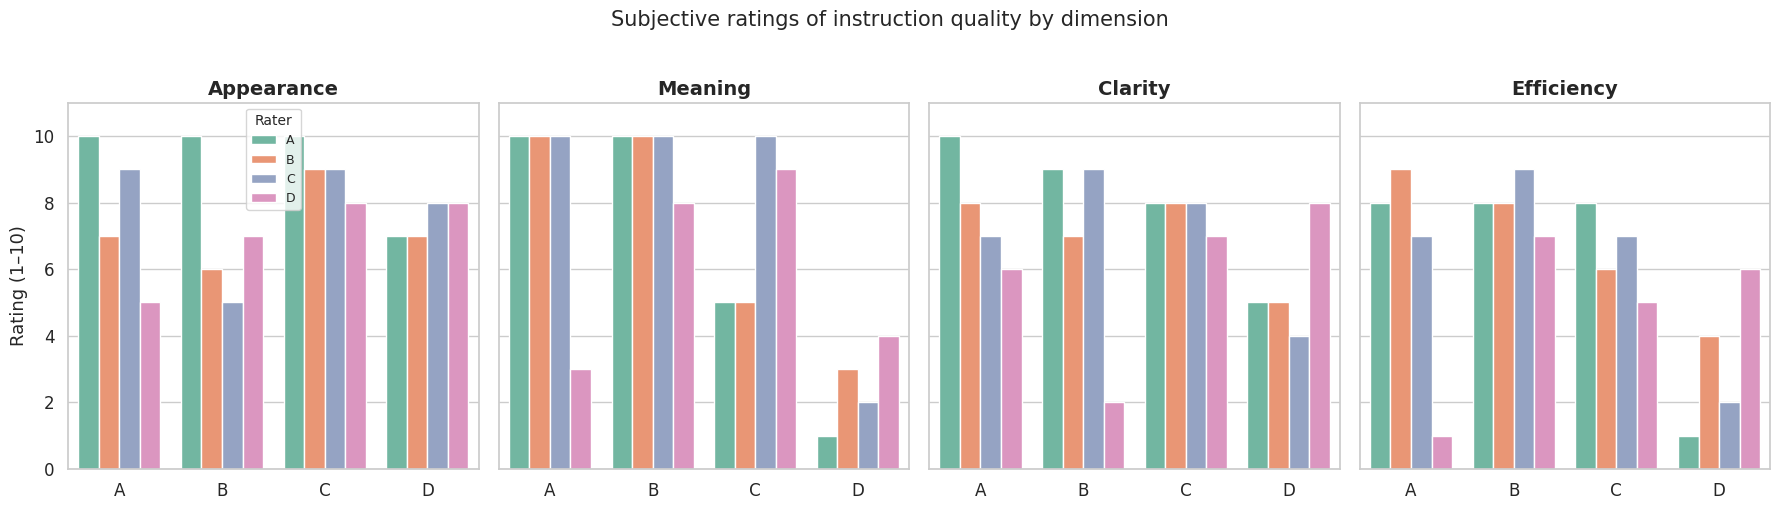

In [17]:
# Grouped bar chart of ratings
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
categories = ['appearance', 'meaning', 'clarity', 'efficiency']
palette = sns.color_palette('Set2', n_colors=len(submitted_groups))

for j, cat in enumerate(categories):
  cat_data = melted_ratings[melted_ratings['Rating category'] == cat]
  sns.barplot(data=cat_data, x='Rated group', y='Rating', hue='Rating group',
              ax=axes[j], palette=palette, errorbar='se', capsize=0.1)
  axes[j].set_title(cat.capitalize(), fontsize=14, fontweight='bold')
  axes[j].set_xlabel('')
  axes[j].set_ylim(0, 11)
  if j > 0:
    axes[j].get_legend().remove()
  else:
    axes[j].legend(title='Rater', fontsize=9, title_fontsize=10)

axes[0].set_ylabel('Rating (1–10)', fontsize=13)
fig.suptitle('Subjective ratings of instruction quality by dimension', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Interactive version with plotly
px.bar(data_frame=melted_ratings, x='Rated group', y='Rating', color='Rating group',
       barmode='group', facet_col='Rating category',
       title='Subjective ratings by dimension and group',
       labels={'Rating': 'Rating (1-10)', 'Rated group': 'Rated Group'})

---
# 5. Statistical tests

## 5a. Pairwise $t$-tests between groups' ratings

For each rating category, we compare every pair of groups using paired-samples $t$-tests (since each rater rated all groups).

**Important caveats:**
- With only a few raters, these tests have very low power — large differences are needed to reach significance
- We're running many tests without correcting for multiple comparisons, so any "significant" results should be interpreted cautiously

In [19]:
from scipy.stats import t as t_dist

def cohens_d_paired(x1, x2):
  """Cohen's d for paired samples."""
  diff = x1 - x2
  return np.nanmean(diff) / np.nanstd(diff, ddof=1)

def ci_mean_diff(x1, x2, confidence=0.95):
  """95% CI for the mean difference (paired)."""
  diff = x1 - x2
  n = np.sum(~np.isnan(diff))
  m = np.nanmean(diff)
  se = np.nanstd(diff, ddof=1) / np.sqrt(n)
  t_crit = t_dist.ppf((1 + confidence) / 2, df=n - 1)
  return m - t_crit * se, m + t_crit * se

for c in categories:
  print(f'\nRatings category: {c.upper()}')
  print('-' * 70)
  for i, g1 in enumerate(all_groups):
    r1 = ratings[f'{c} {g1}'].values.astype(float)
    for g2 in all_groups[(i + 1):]:
      r2 = ratings[f'{c} {g2}'].values.astype(float)
      t, p = ttest_rel(r1, r2)
      df = len(r1) - 1
      d = cohens_d_paired(r1, r2)
      ci_lo, ci_hi = ci_mean_diff(r1, r2)
      sig = ' *' if p < 0.05 else ''
      print(f'  {g1} vs. {g2}: t({df}) = {t:6.3f}, p = {p:.4f}, '
            f'd = {d:.2f}, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}]{sig}')


Ratings category: APPEARANCE
----------------------------------------------------------------------
  A vs. B: t(3) =  0.600, p = 0.5908, d = 0.30, 95% CI [-3.23, 4.73]
  A vs. C: t(3) = -1.667, p = 0.1942, d = -0.83, 95% CI [-3.64, 1.14]
  A vs. D: t(3) =  0.200, p = 0.8543, d = 0.10, 95% CI [-3.73, 4.23]
  B vs. C: t(3) = -2.191, p = 0.1162, d = -1.10, 95% CI [-4.91, 0.91]
  B vs. D: t(3) = -0.397, p = 0.7177, d = -0.20, 95% CI [-4.50, 3.50]
  C vs. D: t(3) =  2.324, p = 0.1027, d = 1.16, 95% CI [-0.55, 3.55]

Ratings category: MEANING
----------------------------------------------------------------------
  A vs. B: t(3) = -1.000, p = 0.3910, d = -0.50, 95% CI [-5.23, 2.73]
  A vs. C: t(3) =  0.383, p = 0.7275, d = 0.19, 95% CI [-7.32, 9.32]
  A vs. D: t(3) =  2.514, p = 0.0866, d = 1.26, 95% CI [-1.53, 13.03]
  B vs. C: t(3) =  1.406, p = 0.2545, d = 0.70, 95% CI [-2.84, 7.34]
  B vs. D: t(3) =  6.481, p = 0.0075, d = 3.24, 95% CI [3.56, 10.44] *
  C vs. D: t(3) =  3.800, p = 0.032

## 5b. Repeated-measures ANOVAs

Instead of running many pairwise tests, we can use a repeated-measures ANOVA to ask: *within each rating category, do the groups differ from each other?* This is a single omnibus test per category, which controls the Type I error rate better than pairwise $t$-tests.

In [20]:
mapper = {'Rating group': 'rating_group', 'Rated group': 'rated_group',
          'Rating category': 'category'}
df_anova = melted_ratings.rename(mapper, axis=1)

print('Repeated-measures ANOVA results:')
print('=' * 70)
for c in categories:
  next_data = df_anova.query(f'category == "{c}"')
  x = AnovaRM(next_data, depvar='Rating', subject='rating_group',
              within=['rated_group'])
  results = x.fit().anova_table
  f_val = results['F Value'].values[0]
  p_val = results['Pr > F'].values[0]
  num_df = results['Num DF'].values[0]
  den_df = results['Den DF'].values[0]

  # Compute eta-squared: η² = SS_effect / SS_total
  ss_between = f_val * num_df  # approximate from F * df_num (since MS_error normalized)
  eta_sq = (f_val * num_df) / (f_val * num_df + den_df)

  sig = ' *' if p_val < 0.05 else ''
  print(f'  {c.capitalize():12s}: F({num_df:.0f}, {den_df:.0f}) = {f_val:.3f}, '
        f'p = {p_val:.4f}, η² = {eta_sq:.3f}{sig}')

Repeated-measures ANOVA results:
  Appearance  : F(3, 9) = 1.332, p = 0.3237, η² = 0.308
  Meaning     : F(3, 9) = 5.934, p = 0.0162, η² = 0.664 *
  Clarity     : F(3, 9) = 1.000, p = 0.4363, η² = 0.250
  Efficiency  : F(3, 9) = 2.767, p = 0.1033, η² = 0.480


## 5c. Assumptions: do groups differ?

We can also test whether some groups' instructions required significantly more assumptions than others.

In [21]:
def cohens_d_ind(x1, x2):
  """Cohen's d for independent samples (nan-safe)."""
  n1 = np.sum(~np.isnan(x1))
  n2 = np.sum(~np.isnan(x2))
  var1 = np.nanvar(x1, ddof=1)
  var2 = np.nanvar(x2, ddof=1)
  pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
  if pooled_std == 0:
    return 0.0
  return (np.nanmean(x1) - np.nanmean(x2)) / pooled_std

def ci_mean_diff_ind(x1, x2, confidence=0.95):
  """95% CI for difference in means (independent, nan-safe)."""
  n1 = np.sum(~np.isnan(x1))
  n2 = np.sum(~np.isnan(x2))
  m_diff = np.nanmean(x1) - np.nanmean(x2)
  se = np.sqrt(np.nanvar(x1, ddof=1) / n1 + np.nanvar(x2, ddof=1) / n2)
  df_val = n1 + n2 - 2
  t_crit = t_dist.ppf((1 + confidence) / 2, df=df_val)
  return m_diff - t_crit * se, m_diff + t_crit * se

# Compare each group's assumption counts to all other groups
print('Assumption count comparisons (each group vs. all others):')
print('=' * 75)
for g in all_groups:
  ref = compiled_assumptions.query('rated == @g')['count'].values.astype(float)
  other = compiled_assumptions.query('rated != @g')['count'].values.astype(float)
  n_ref = np.sum(~np.isnan(ref))
  n_other = np.sum(~np.isnan(other))
  if n_ref > 0 and n_other > 0:
    result = ttest_ind(ref, other, nan_policy='omit')
    df_val = n_ref + n_other - 2
    d = cohens_d_ind(ref, other)
    ci_lo, ci_hi = ci_mean_diff_ind(ref, other)
    sig = ' *' if result.pvalue < 0.05 else ''
    print(f'  Group {g} (M={np.nanmean(ref):.1f}) vs. others (M={np.nanmean(other):.1f}): '
          f't({df_val}) = {result.statistic:.3f}, p = {result.pvalue:.4f}, '
          f'd = {d:.2f}, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}]{sig}')
  else:
    print(f'  Group {g}: insufficient data')

Assumption count comparisons (each group vs. all others):
  Group A (M=2.0) vs. others (M=3.7): t(14) = -1.250, p = 0.2318, d = -0.72, 95% CI [-4.13, 0.80]
  Group B (M=2.5) vs. others (M=3.5): t(14) = -0.725, p = 0.4807, d = -0.42, 95% CI [-3.95, 1.95]
  Group C (M=4.0) vs. others (M=3.0): t(14) = 0.725, p = 0.4807, d = 0.42, 95% CI [-1.77, 3.77]
  Group D (M=4.5) vs. others (M=2.8): t(14) = 1.250, p = 0.2318, d = 0.72, 95% CI [-1.70, 5.03]


---
# 6. Closing thoughts

What do you think makes a "good" methods section? Is it one that other people *think* is clear? Or one that results in outcomes similar to the intended outcome? Or one that spells out every step in a way that requires minimal assumptions (and therefore potential for misinterpretation)?

The analyses outlined in this notebook are far from comprehensive. Some other ideas to explore:

- **Self vs. other ratings**: Are there groups who rated themselves much differently than other groups rated them? What does that mismatch tell us?
- **Instruction complexity**: How did the number of instructions, word count, or visual complexity relate to accuracy?
- **Robustness**: Were some drawings more "forgiving" of errors — i.e., recognizable even when instructions weren't followed perfectly?
- **Text analysis**: Could particular wordings or phrasings predict instruction-following accuracy?
- **Correlation between measures**: Do the "objectively best" instructions (highest following rate) also get the highest subjective ratings?

Try playing around with the data and see if anything interesting (or unexpected!) pops out!